# Graphs

After we got our simulaiton to run properly, we shifted our focus onto data analysis.\
All of the following graphs focus on analyzing two key measurements: average flow, and jamming fractions.

## Average Flow

We defined this measure as the average velocity of our cars times the density of cars in our grid.\
This was achieved thorought the following lines of code:
```
def average_flow(self, grid):
        """
        Compute the average flow: 
        flow = density * average velocity = (#cars / n) * mean velocity of cars
        """
        cars = grid[grid >= 0]          
        if len(cars) == 0:
            return 0
        return (len(cars) / (self.cells * self.lanes)) * np.mean(cars)
```
- Note this only analyzed this measurement for a given grid state.

We then further developed this to measure the mean value of the 'average flow' over the course of our simulations.\
The code refers to this second measure as the "history average flow" and is defined by the following code:
```
def history_average_flow(self):
        """
        The average "average flow" over the total simulation history.
        """
        sum_average_flow, counter = 0, 0
        for grid in self.history:
            counter += 1
            sum_average_flow += self.average_flow(grid)
        return sum_average_flow / counter

```
- All of the finalized data used this "history average flow", as it allowed us to analyze the steady state of our system.

## Jamming Fraction

Similar to average flow, the jamming fraction is a measurement of our car's velocity.\
It differs by measuring the total amount of cars with exactly zero velocity over the total amount of cars.\
This was achieved through the following lines of code:
```
def jam_fraction(self, grid):
        """
        Fraction of cars that are part of a jam.
        A 'jam' is defined as a car with velocity 0.
        """
        cars = grid[grid >= 0]
        if len(cars) == 0:
            return 0
        return np.sum(cars == 0) / len(cars)
```
- This also only analyzed a single grid state.

We also developed a "history jamming fraction" method in order to measure the mean jamming fraction over a simulation's history.\
This was measured through the following code:
```
def history_jam_fraction(self):
        """
        The average "jam fraction" over the total simulation history.
        """
        sum_jam_fraction, counter = 0, 0
        for grid in self.history:
            counter += 1
            sum_jam_fraction += self.jam_fraction(grid)
        
        return sum_jam_fraction / counter
```
- This was also used for our final results.


# Initial (Outdated) Measurements

When we first made our measurements, our results were not entirely accurate to the actual simulation results.\
This was only found after our presentation, where we realized that our simulation's fixed random state was interfering with the plotting implementation.\
This resulted in significantly skewed data, which would only skew with further simulation time.\
Here are those initial results:

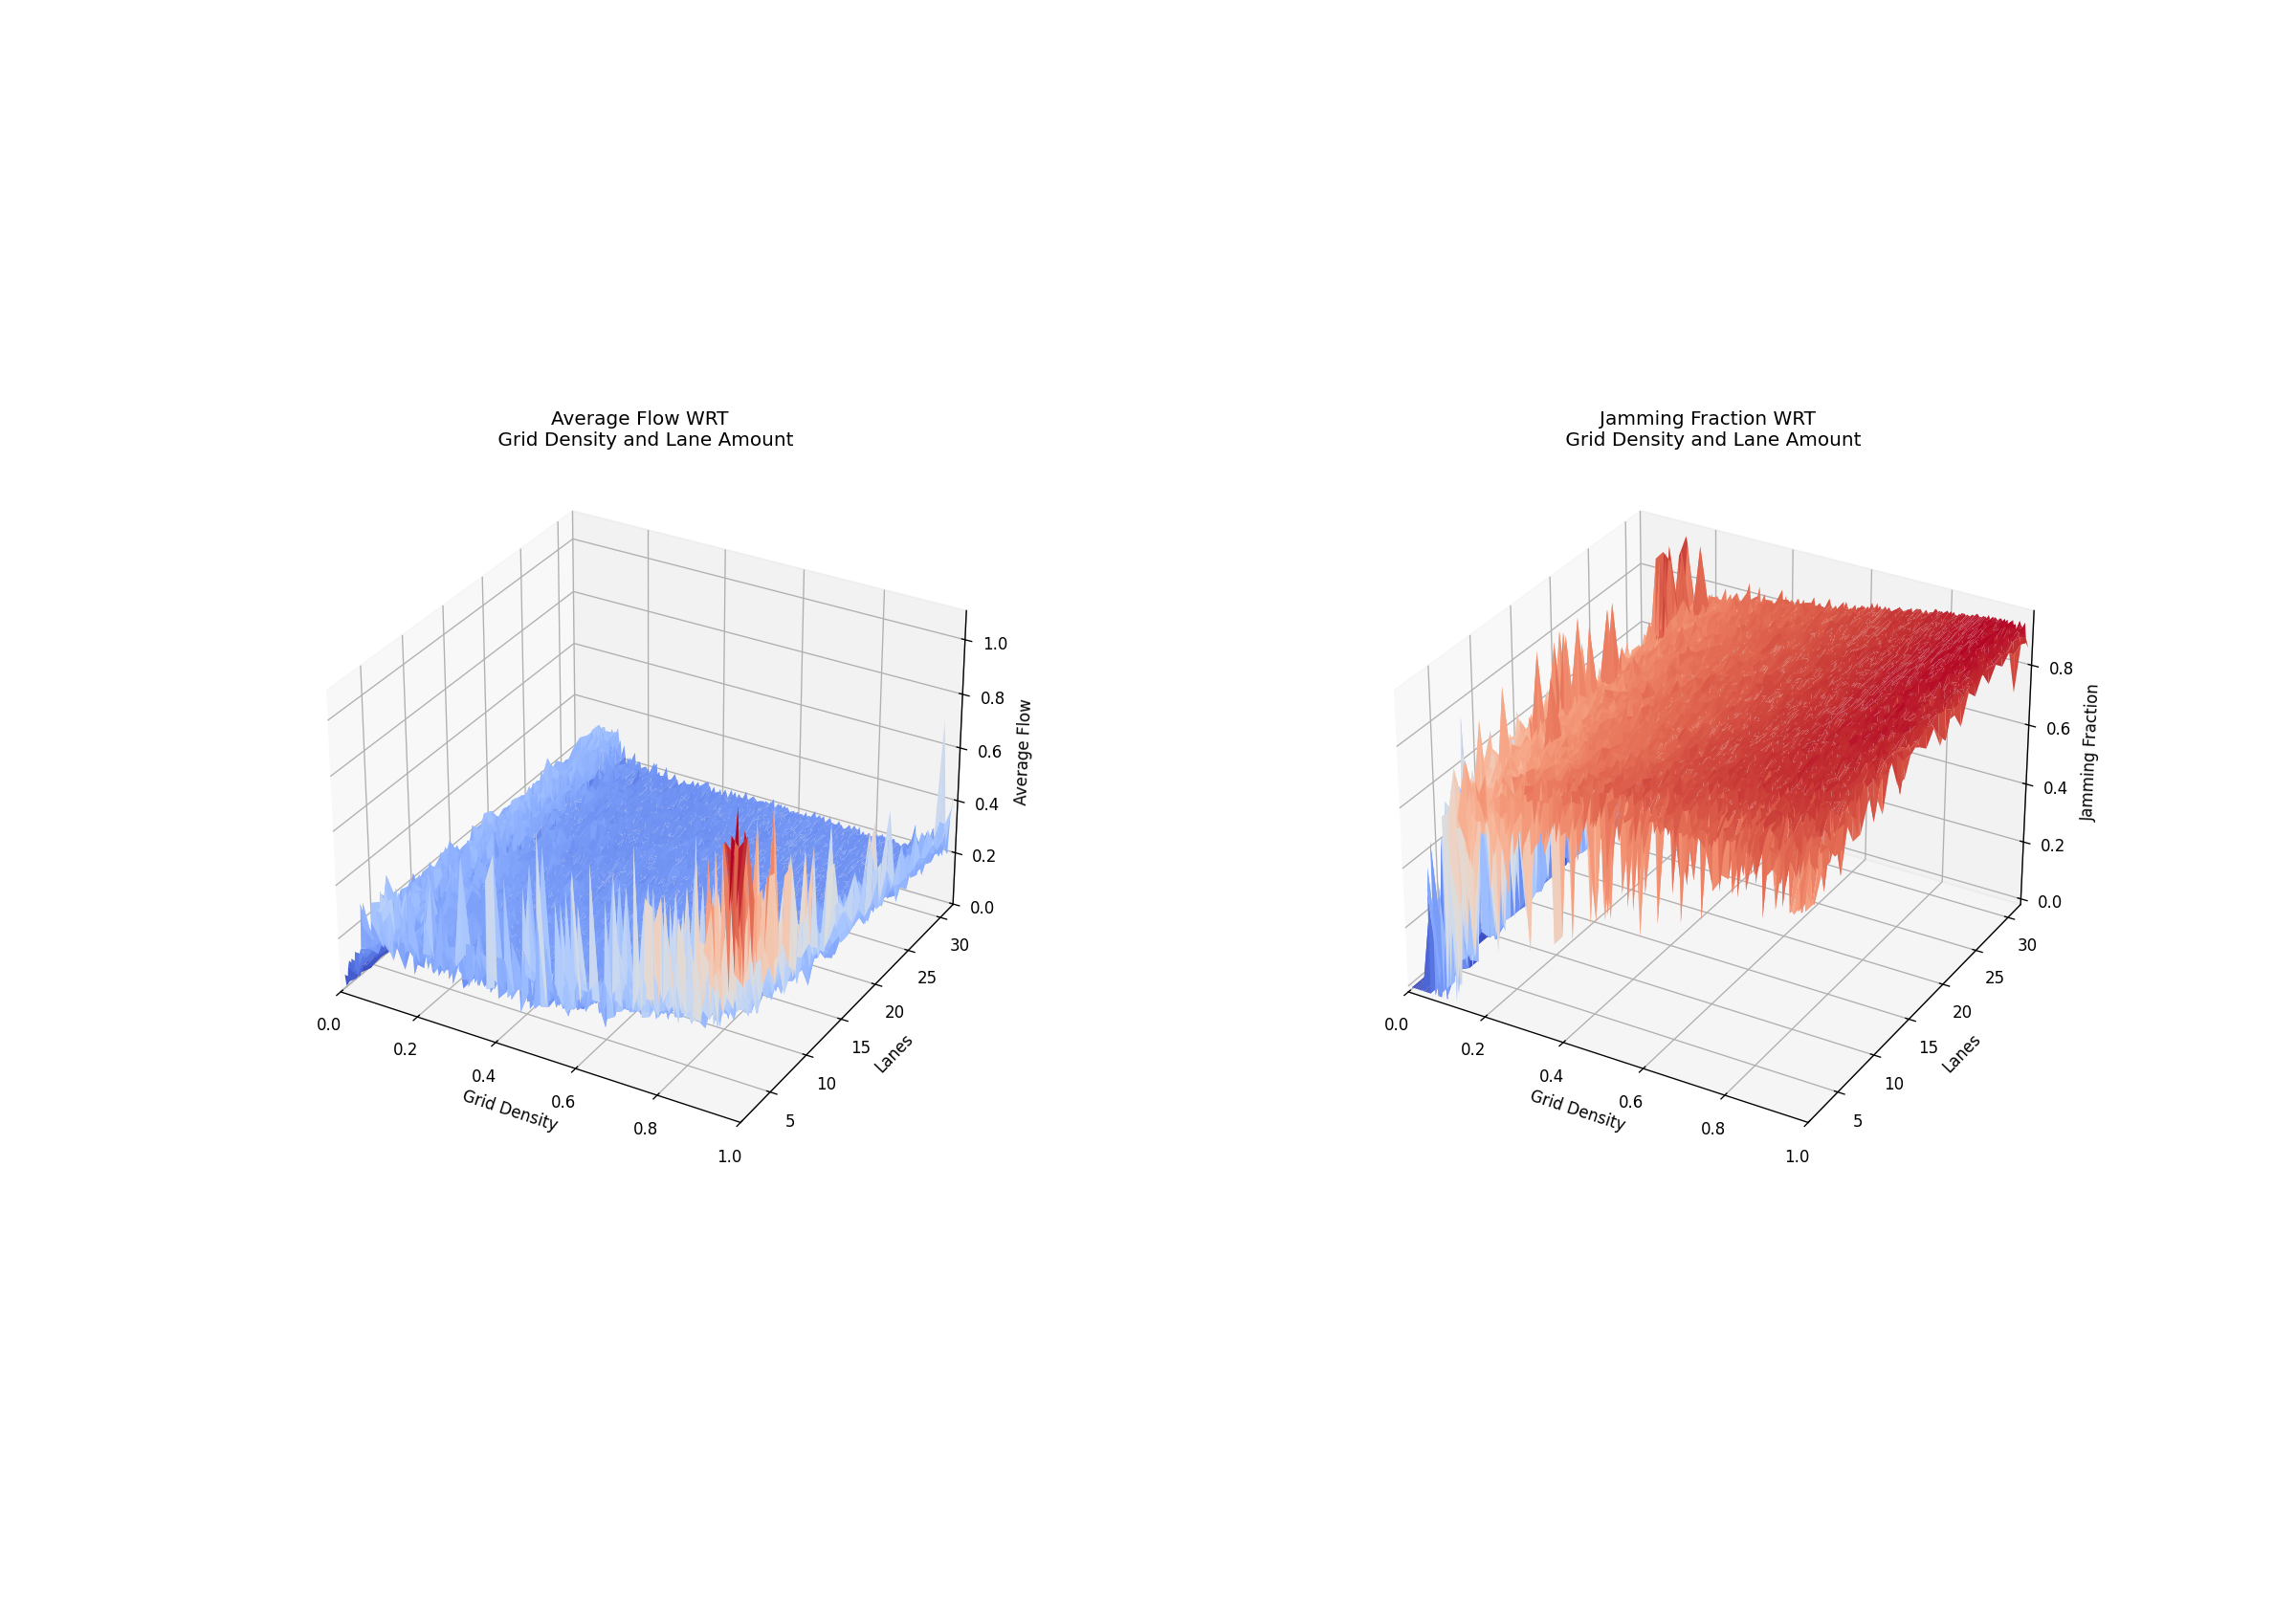
- This graph used a threshold value to stop the increments early, but was clearly incorrect. It implied that high densities with low laned had a superior throughput to any other combination, which is clearly false.

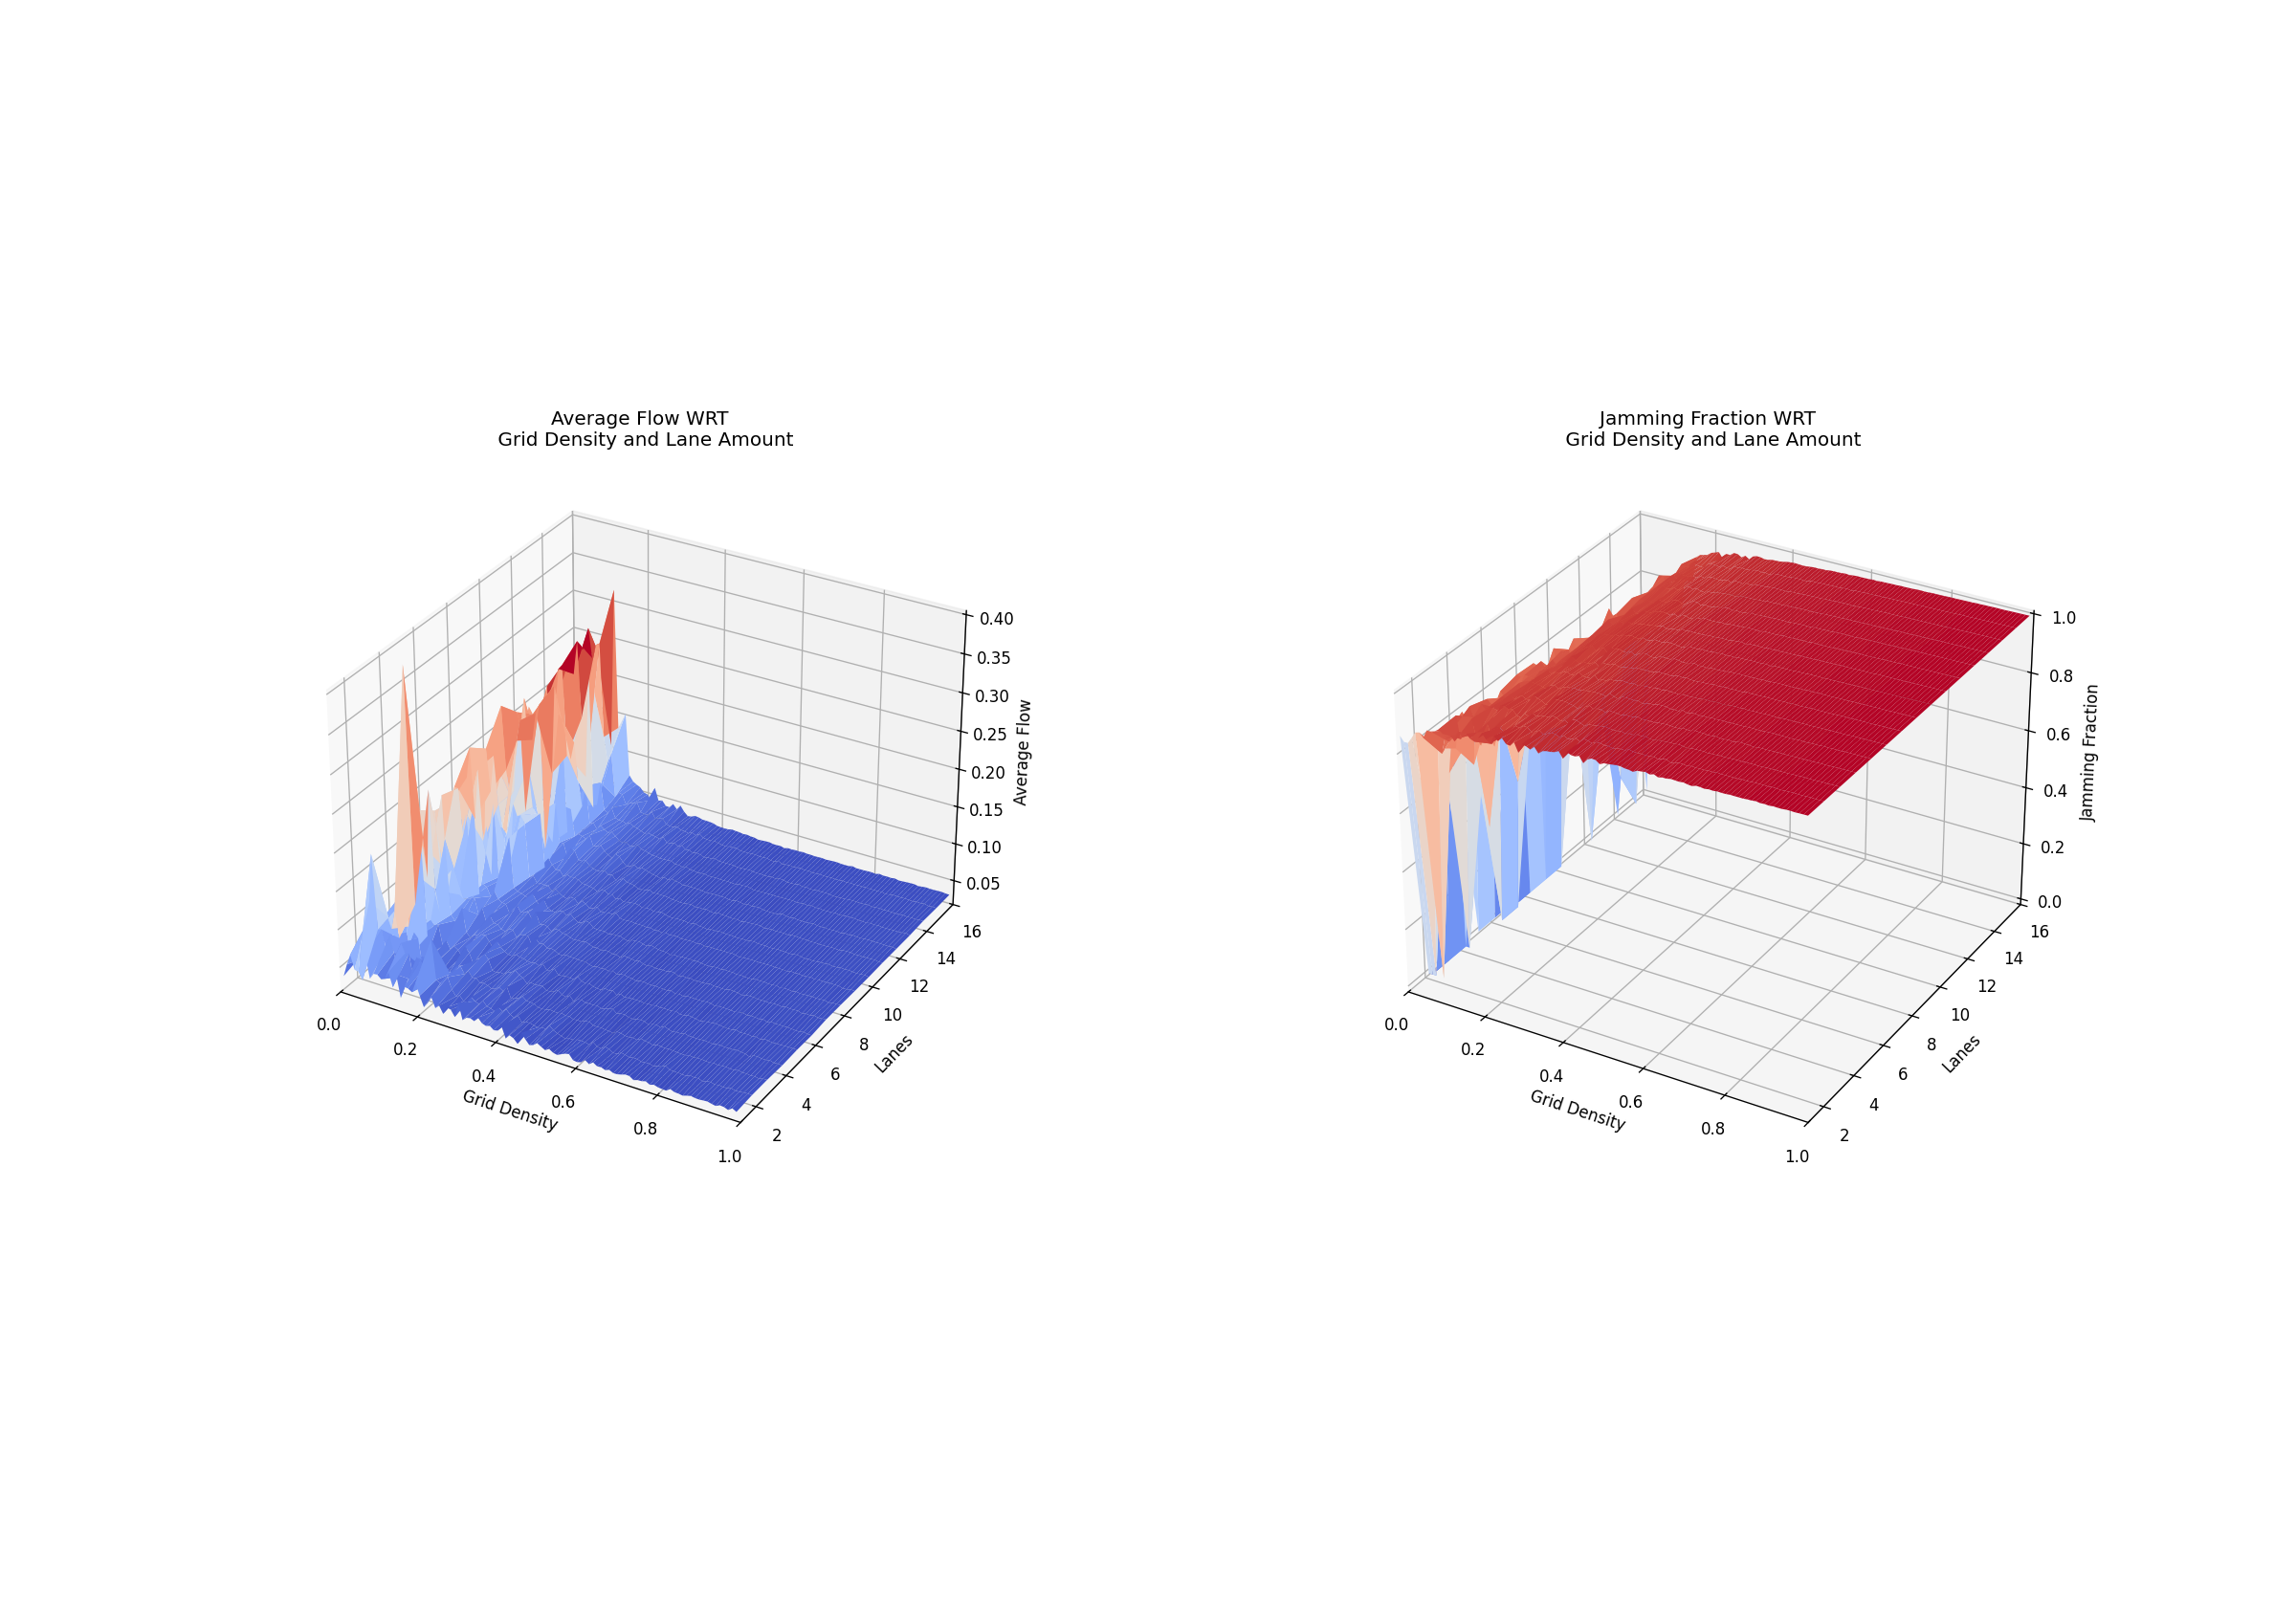
- By not including an error tolerance, we were able to show that low density grids had significantly higher throughput, and that higher lane counts tended to increase this rate.

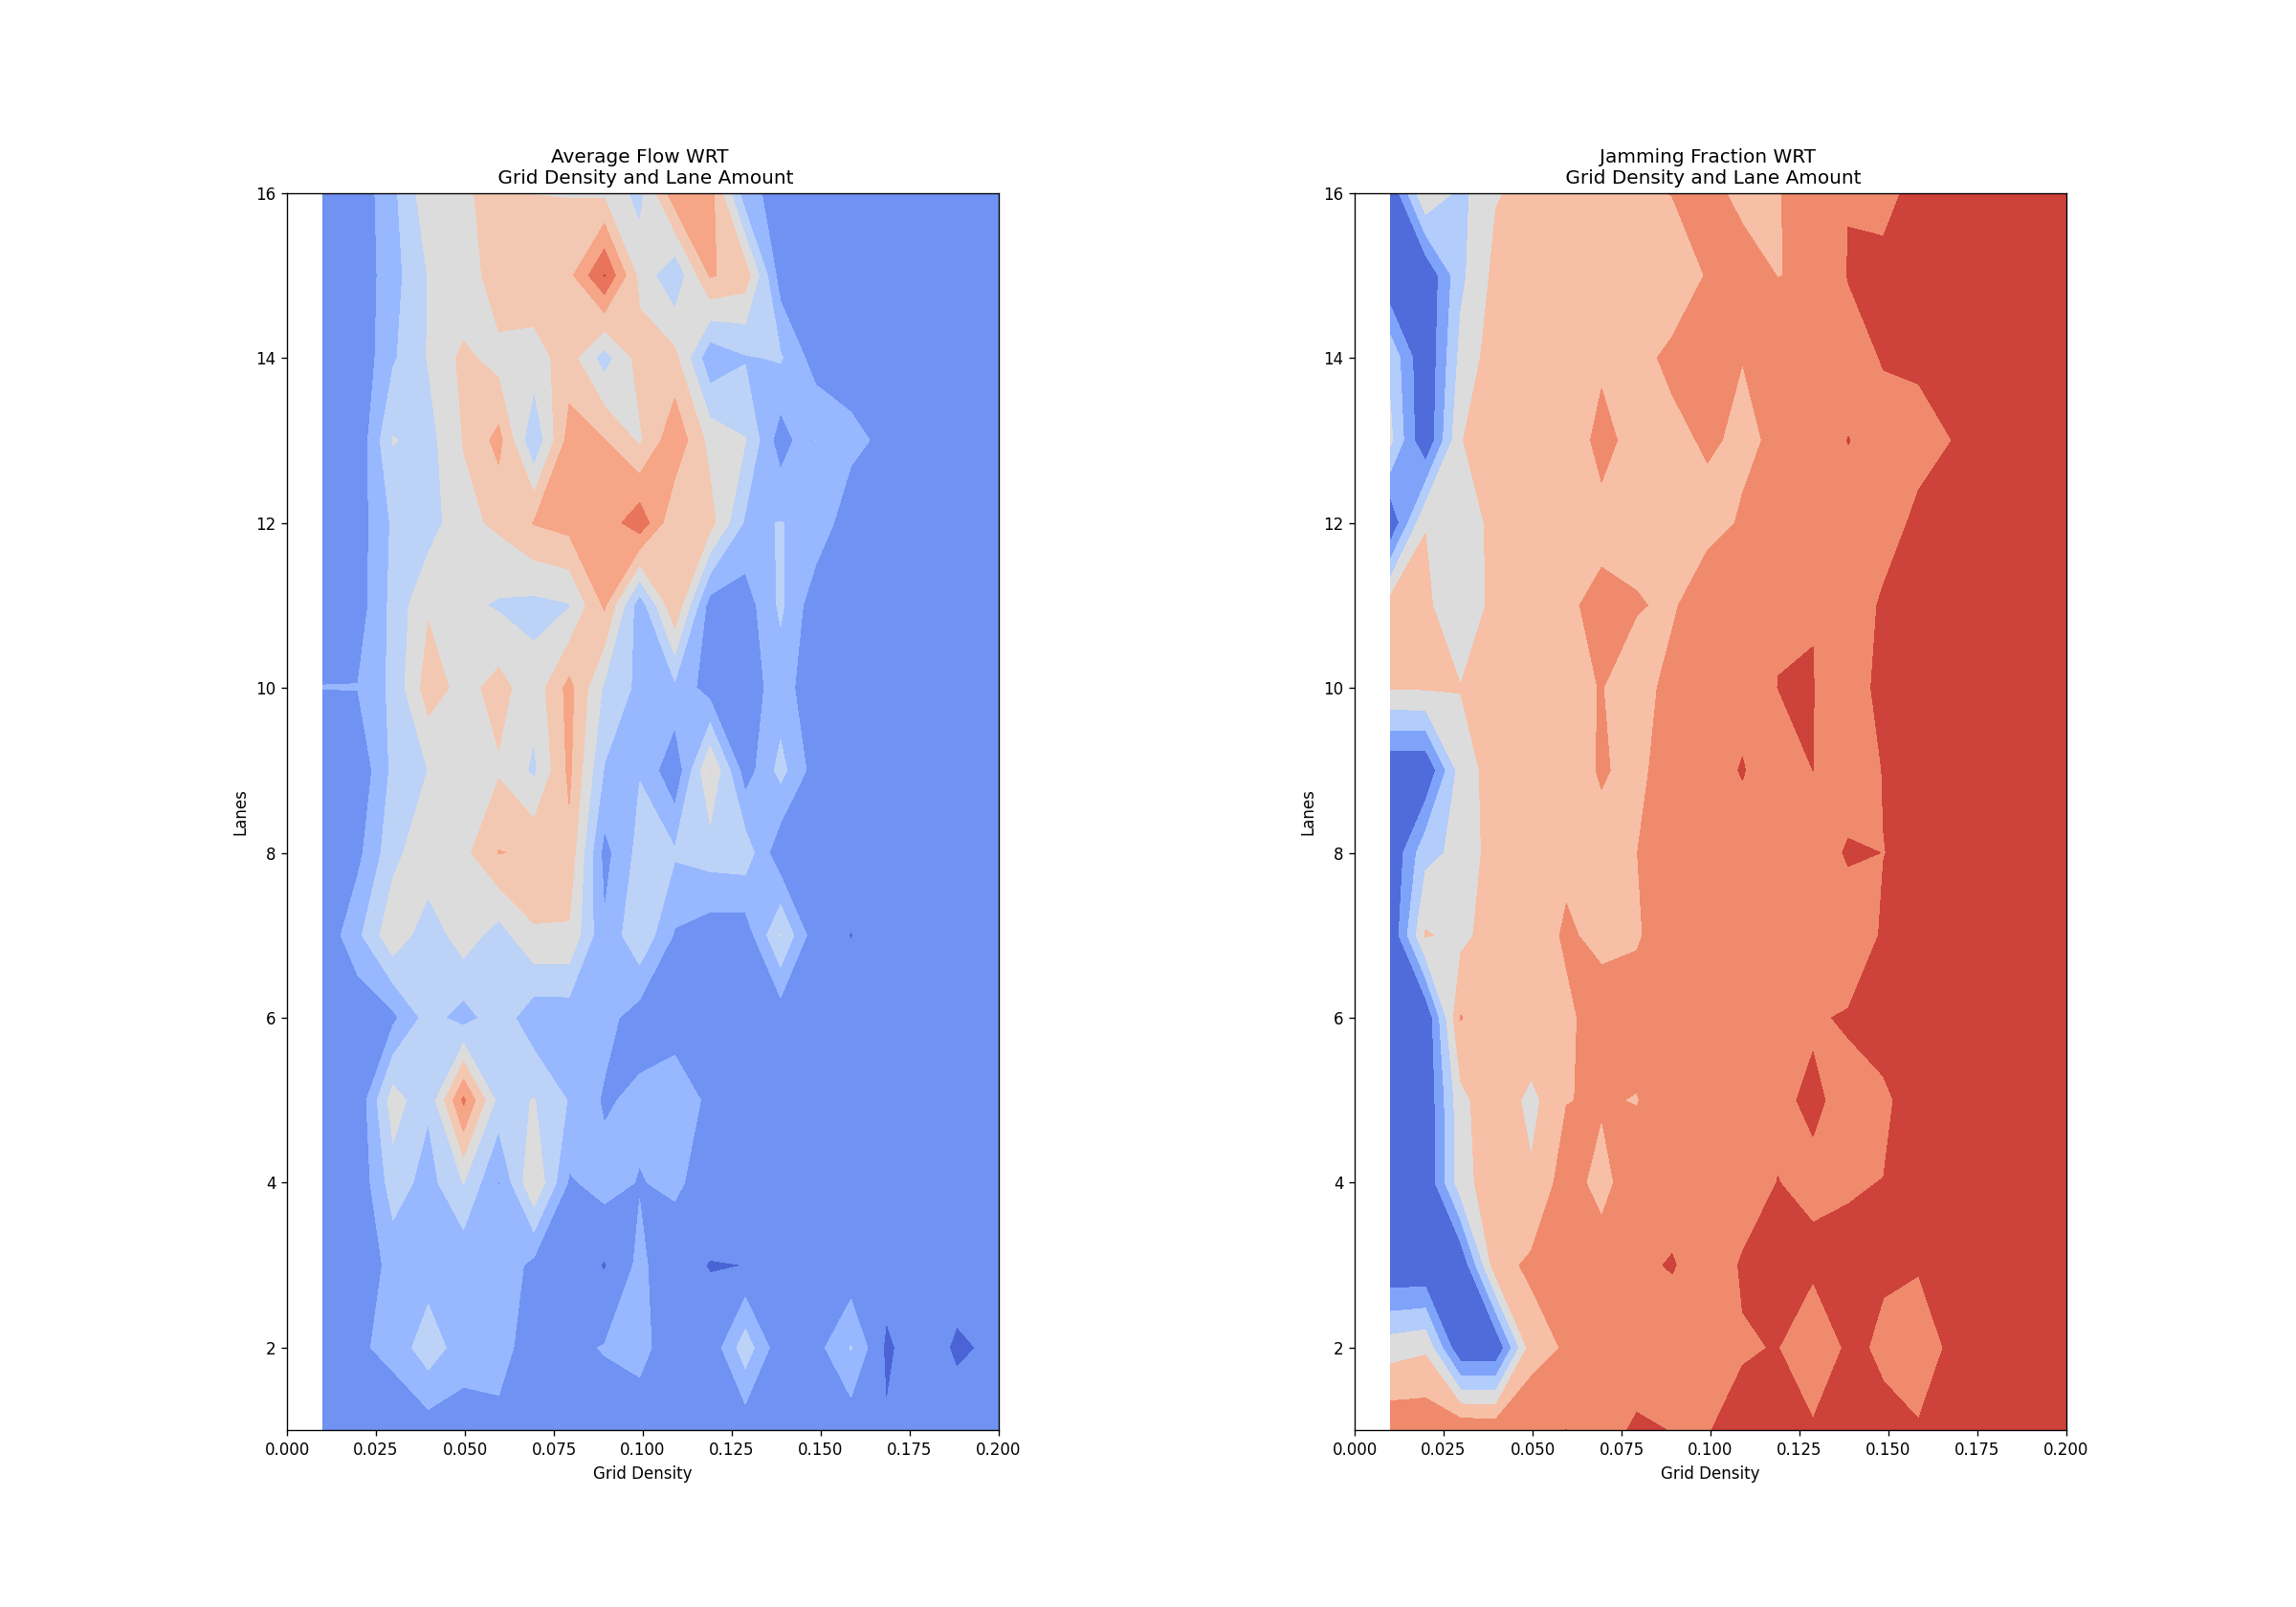
- This is just a 2D colormap of the previous graph to highlight the results.

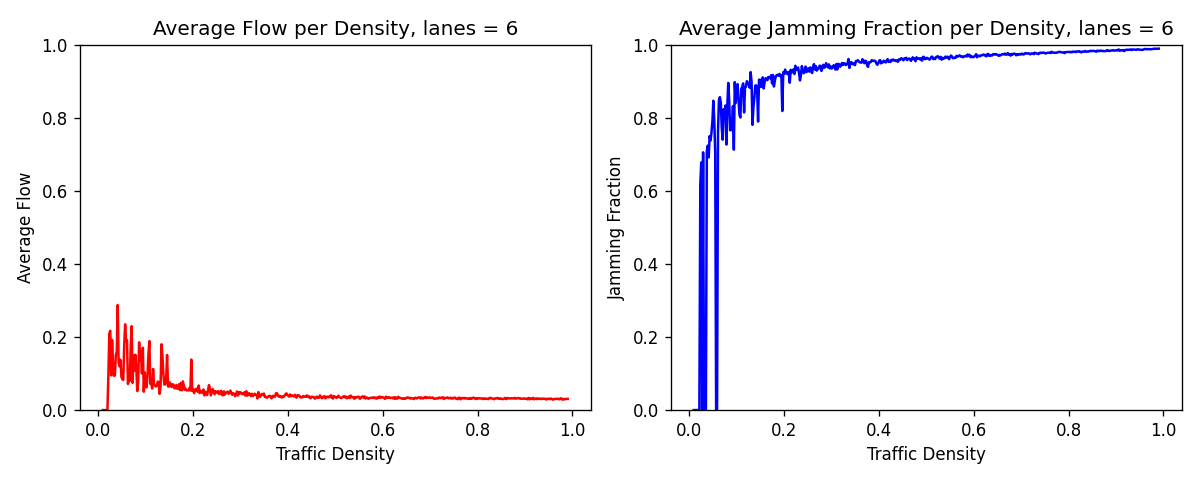
- This results focused on a single lane measurement across varying densities. However, we knew this result was askew as low density rates should have produces far higher average flows.

### Energy Analysis

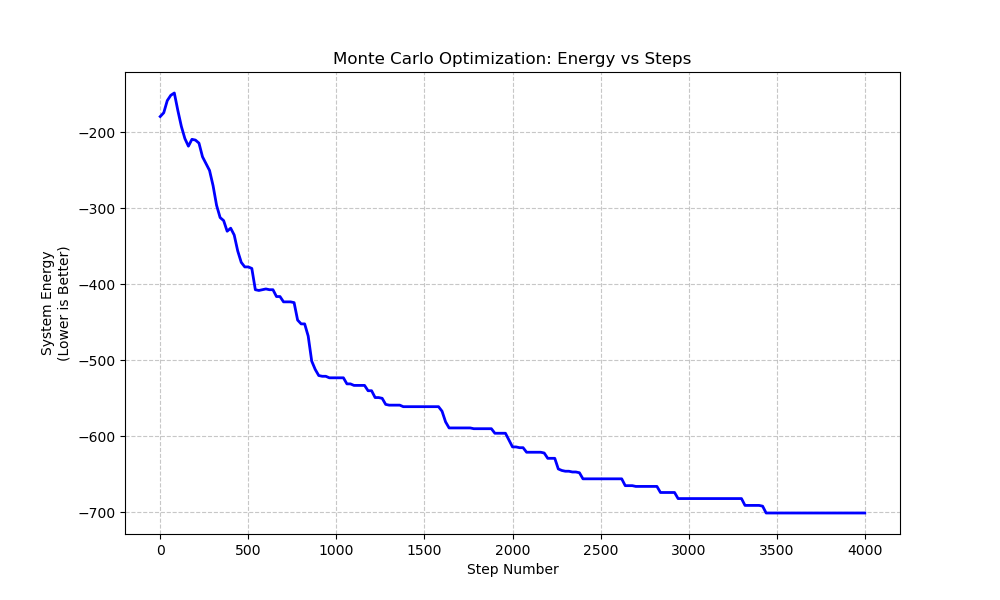
- We also measured the average energy of our system (I don't know how), and found that it steadily approached a minimum over time.

# Specific Lane Results

This portion focused on specific lanes to test whether our model was accurate, and how much the initial parameters affected the results.\
Because all of these results had a fixed lane count, we varried the grid's density.\
These results were taken after we realized the fixed initial random state was disrupting our results.

### Single lanes

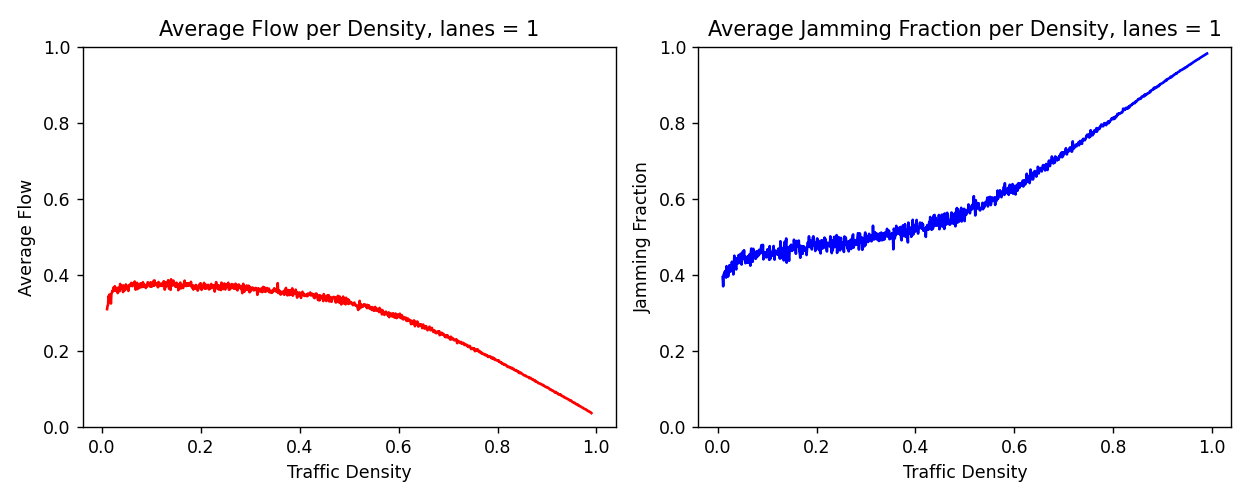
- This graph focused on a single lane model, with 100 simulation steps per density. There were no error threshold, so each point ran for a full 100 steps.

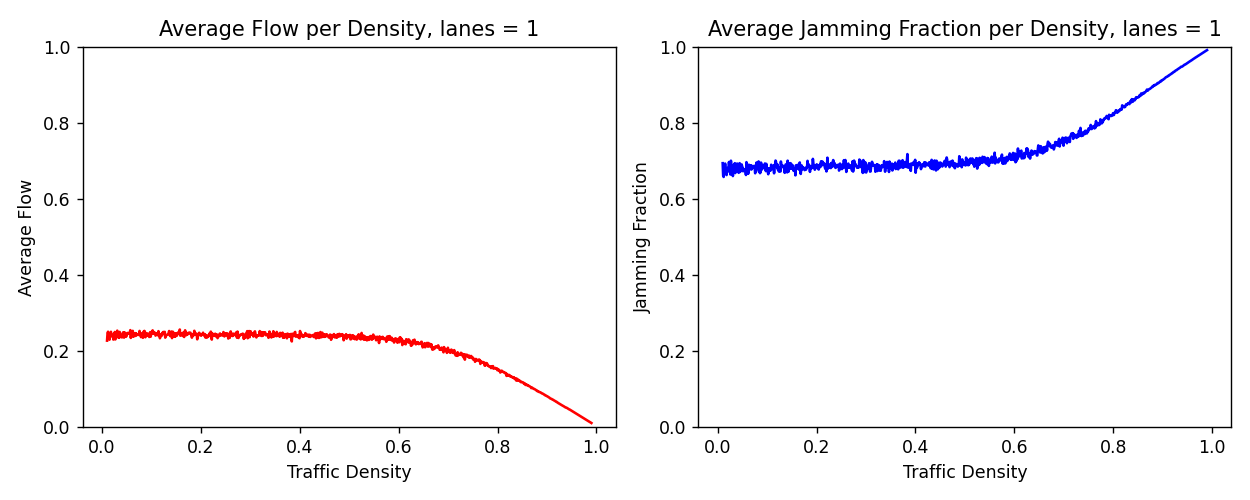
- This graph focused on a single lane model, with 1000 simulation steps per density. There were no error threshold, so each point ran for a full 1000 steps.

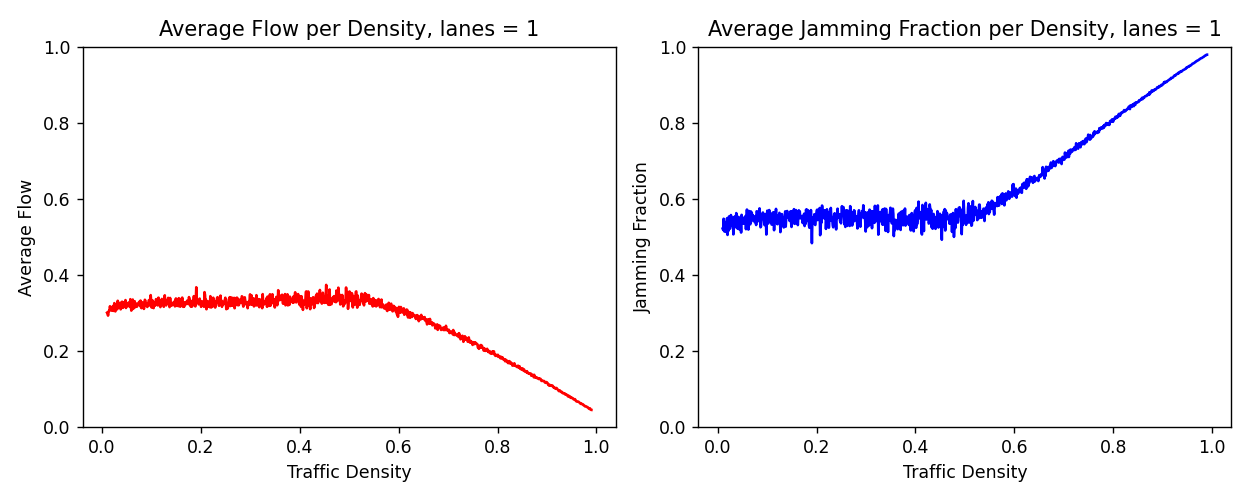
- This graph focused on a single lane model, with 1000 simulation steps per density. There was an error threshold of 0.5*e-3.

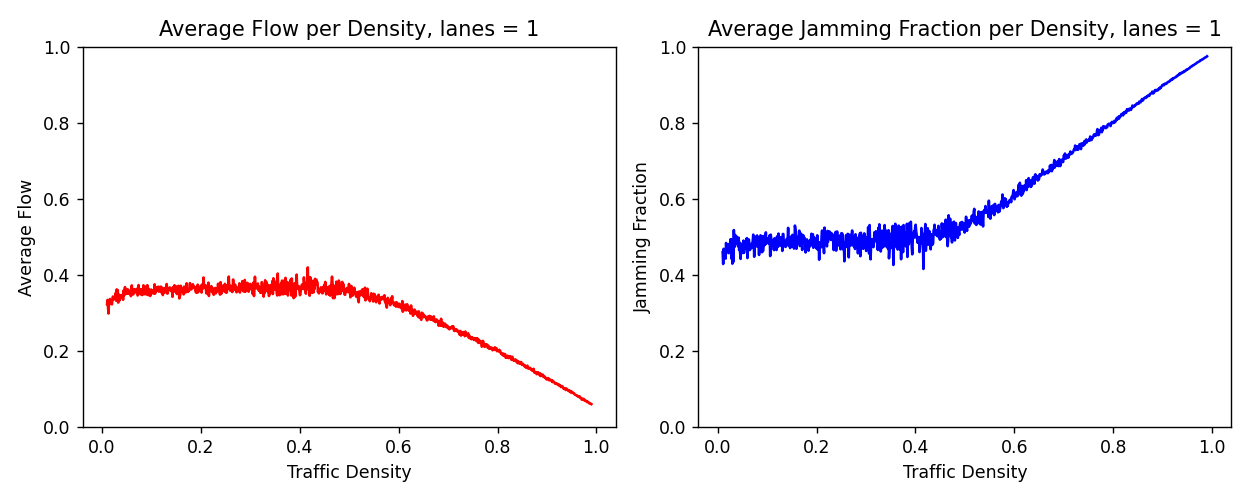
- This graph focused on a single lane model, with 1000 simulation steps per density. There was an error threshold of 1*e-3.

An important takeaway is that the mean measurements tended to differ with iteration steps, which also explains why the error threshold changed the magnitude of the measurements.\
Although the magnitude changes from graph to graph, the overal curvature did not, indicating that our general conclusions would still hold.

### Six Lane System

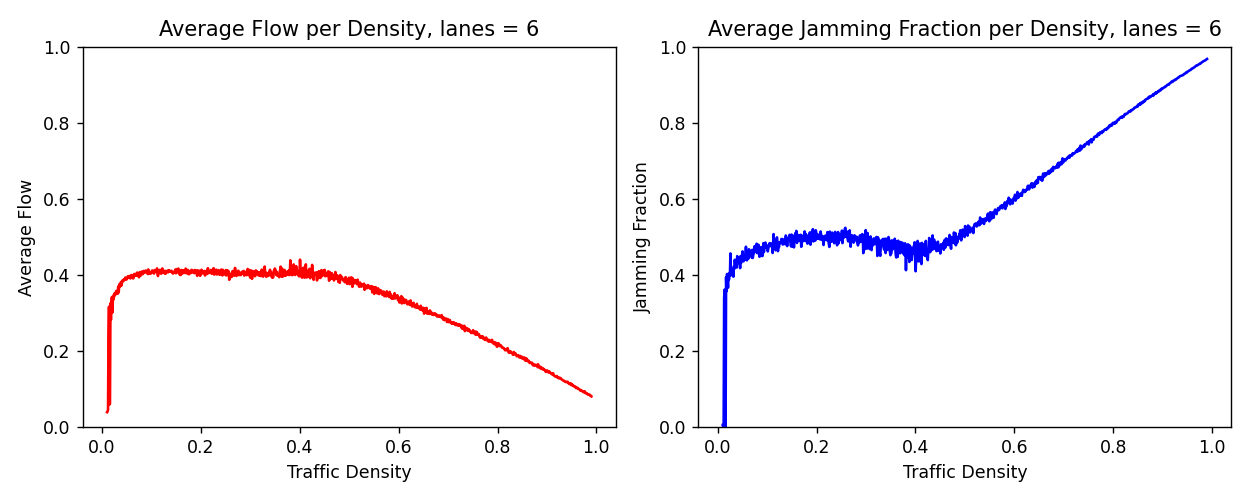
- This graph focused on a six lane model, with 1000 simulation steps per density. There was an error threshold of 2*e-3.

This graph showed starkly distinct results from the single lane model, as the overal shape of the graphs changed significantly. 

# Density & lane Analysis

For our final graphs, we analyzed how both the lane count and grid density affected the statistical measurements.\

### Error Tolerance

This first set of graphs were ran with a tolerance of 1*e-1 over the course of 1000 steps per point. Because of the high tolerance, we believe these results are not indicative of any general trend.

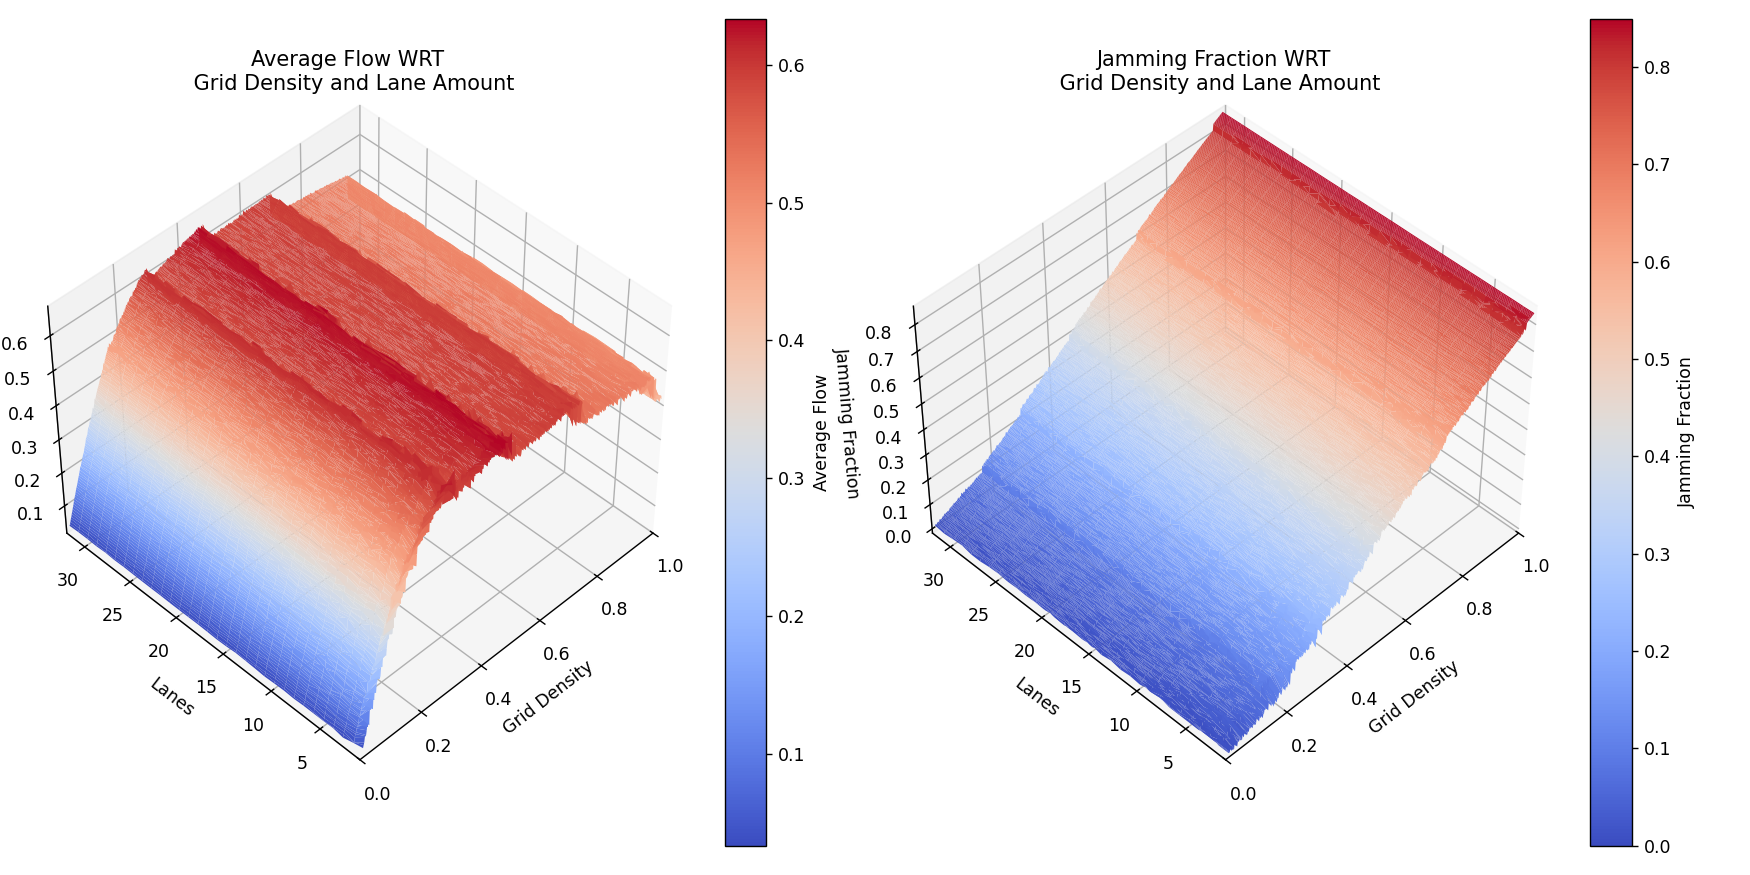
- This graphs shows the measuremetns in 3D. Interestingly we see that with this simulation method the measurements seemed to depend on ony the density, which does not reflect realistic results.

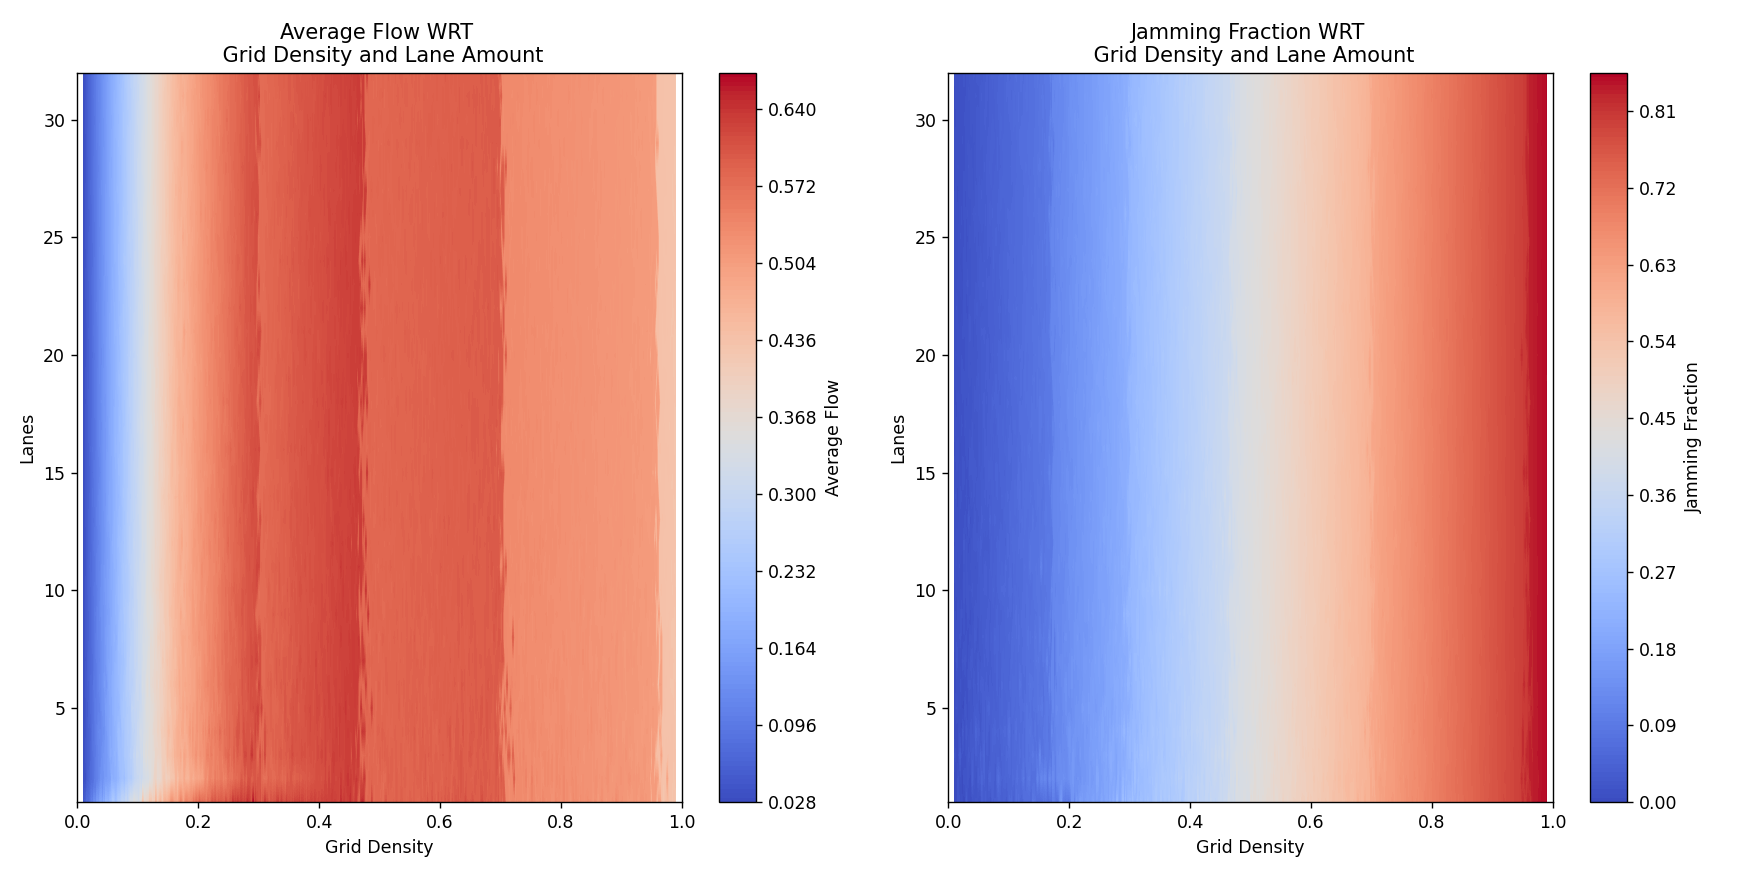
- This is a 2D colorplot of the previous graph. It does show a slight behavior shift between the single and second lane rows, but it was not significant enough to warrant further investigation.

### Smaller Range

This second set of graphs was run over a much smaller parameter range, but with no exceptions to the simulation state. The results seemed far more realistic, and we believe they are more indicative of our model's behavior because each point was sampled from the same iteration step.

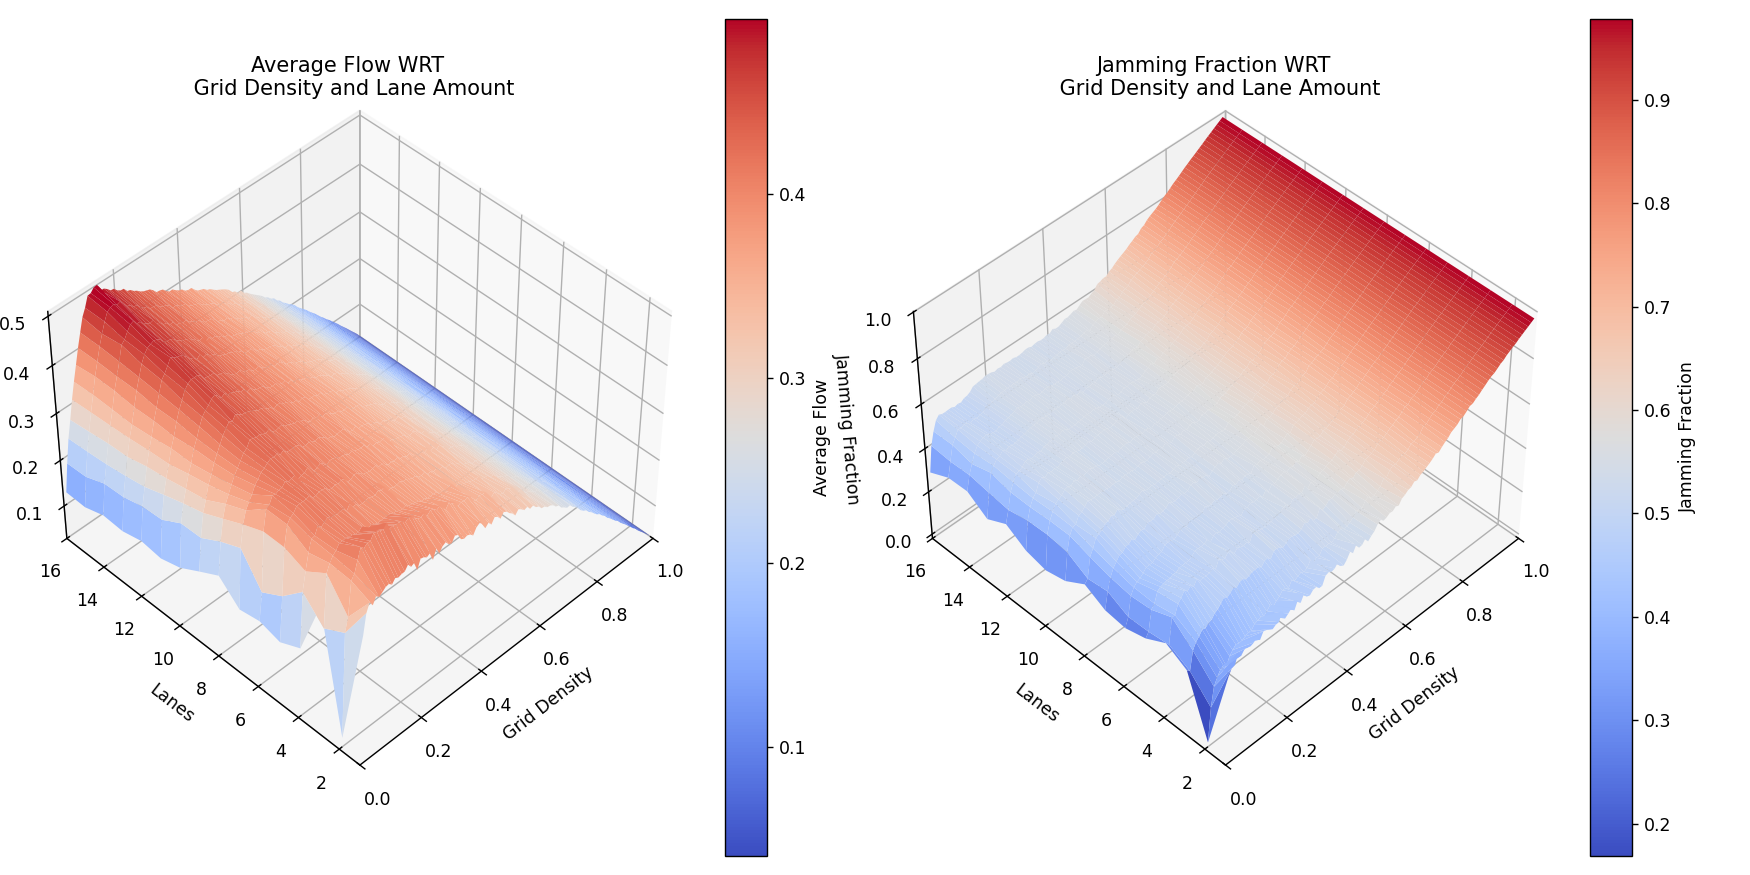
- This graph shows a clear trend that traffic tends to flow best when the grid density is less than 50%, and also showed that with a density of 20%, increasing the amount of lanes in a system drastically increases the flow rate without effecting the jamming fraction. It also showed that systems with lane counts near 2 have a minimum jamming fraction for low densities, which also explains why the average flow has a local maximum near that range of values.

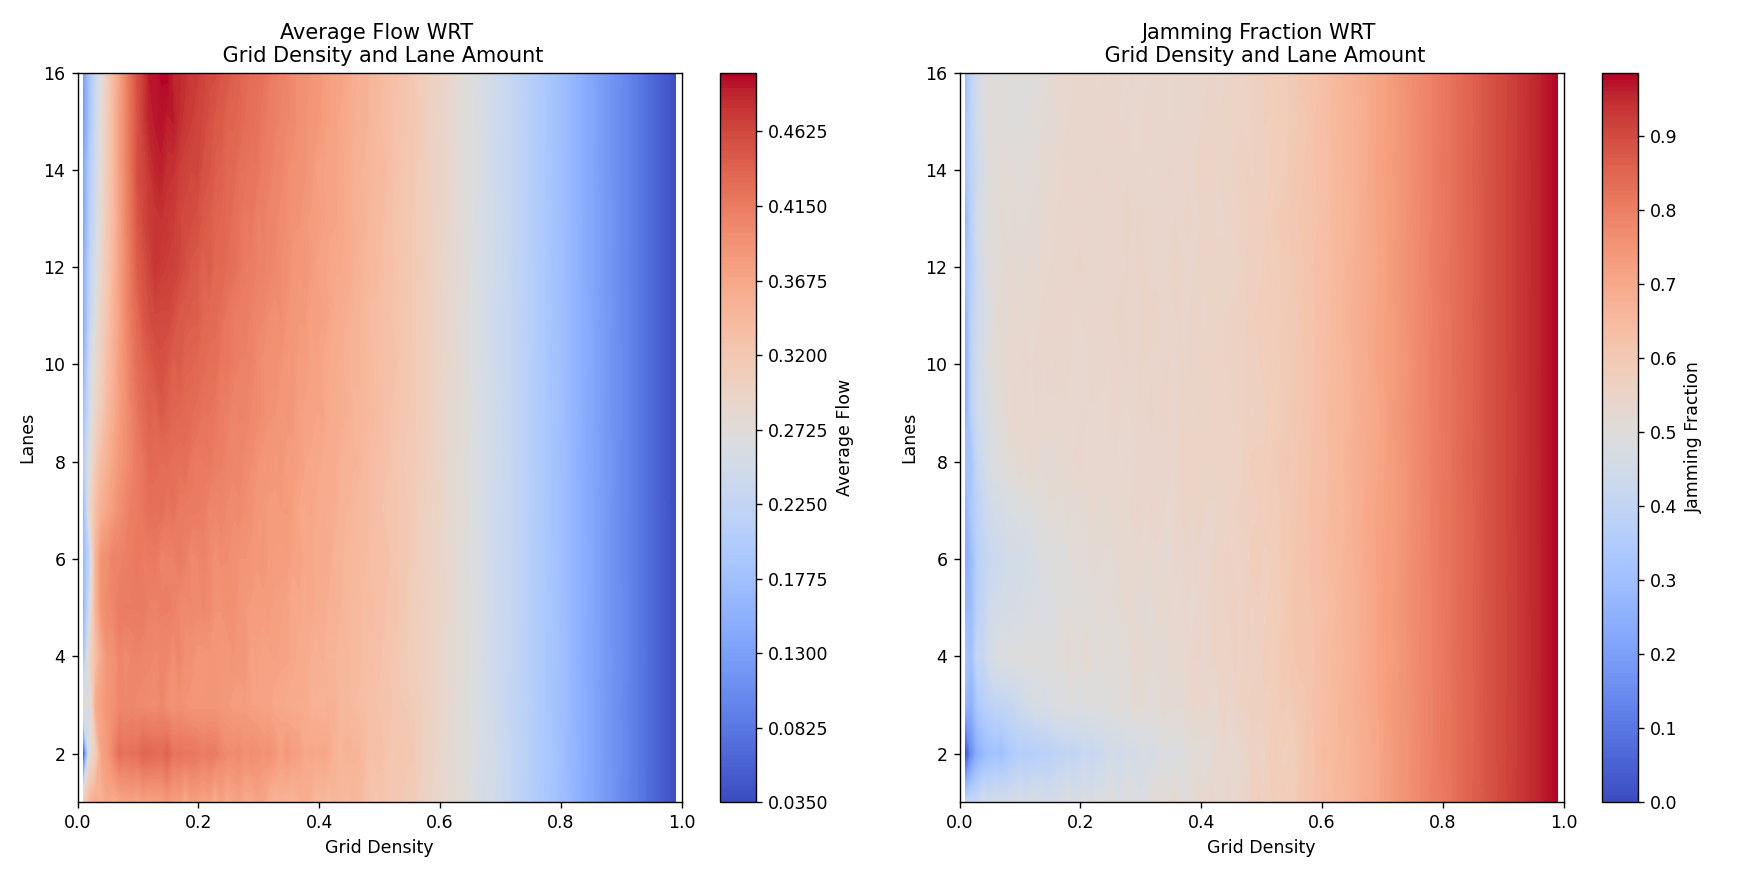
- This 2D colorplot of the previous graph more clearly shows the trends.